## Imports

In [1]:
from matplotlib import pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

from sentropy import sentropy

np.random.seed(42)

# Image sources

Emojis: Apple standard

## Functions

In [2]:
def species_freq(y, outfile, figsize = (4, 2), linewidth = 3):
    x = list(range(len(y)))
    plt.figure(figsize=figsize)
    plt.bar(x, y, linewidth=linewidth, edgecolor="#000", facecolor="#eee")
    ax = plt.gca()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_linewidth(3) # set_visible(True)
    plt.ylim(0, 31)
    plt.savefig(outfile, transparent=True)
    return

def D1(y):
    tot = sum(y)
    P = [i/tot for i in y]
    return np.exp(-sum([i*np.log(i) for i in P]))

def similarity_matrix(S, outfile, scale=1, cmap="bone_r"):
    S = S**scale                    # if values are too close to 1, scale makes it easier to see differences
    figsize = (len(S), len(S))
    plt.figure(figsize=figsize)
    ax = sns.heatmap(S, cmap=cmap, cbar=False, vmin=0., vmax=1.)
    ax.axhline(y=0, color='k', linewidth=3)
    ax.axvline(x=0, color='k', linewidth=3)
    ax.axhline(y=len(S), color='k', linewidth=3)
    ax.axvline(x=len(S), color='k', linewidth=3)
    _ = plt.tight_layout()
    _ = plt.xticks([])
    _ = plt.yticks([])
    _ = plt.tight_layout()
    _ = plt.savefig(outfile, transparent=True)
    _ = plt.show()
    return

## Figure 1: Illustrates the effect of frequency on diversity

This section goes with Fig. 1 from the manuscript.

The icons are all standard Apple emojis. We generate the species-frequency distributions as follows.

### Set 1a (mostly apples)

1.896549191899248

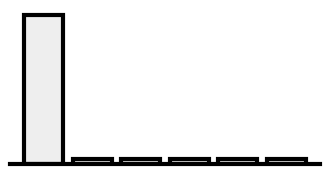

In [3]:
y1 = [30, 1, 1, 1, 1, 1]
species_freq(y1, outfile="fig1_community1a_apples_species_freq_distr.pdf"); D1(y1)

### Set 1b (all fruits)

5.98726389483273

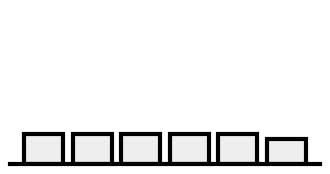

In [4]:
y2 = [6, 6, 6, 6, 6, 5]
species_freq(y2, outfile="fig1_community1b_fruits_species_freq_distr.pdf"); D1(y2)

In [5]:
counts_1a = np.array([30, 1, 1, 1, 1, 1])

In [6]:
# Recall that by default, viewpoint parameter is 1 and measure is 'alpha'.
sentropy(counts_1a)

1.8965491918992476

In [7]:
counts_1b = np.array([6,6,6,6,6,5])

In [8]:
sentropy(counts_1b)

5.98726389483273

## Figure 2: Illustrates the effect of similarity on diversity

As above, the icons are all standard Apple emojis. We generate the heatmaps as follows.

### Set 2a (all birds)

For birds, we just make a random matrix with high similarity.

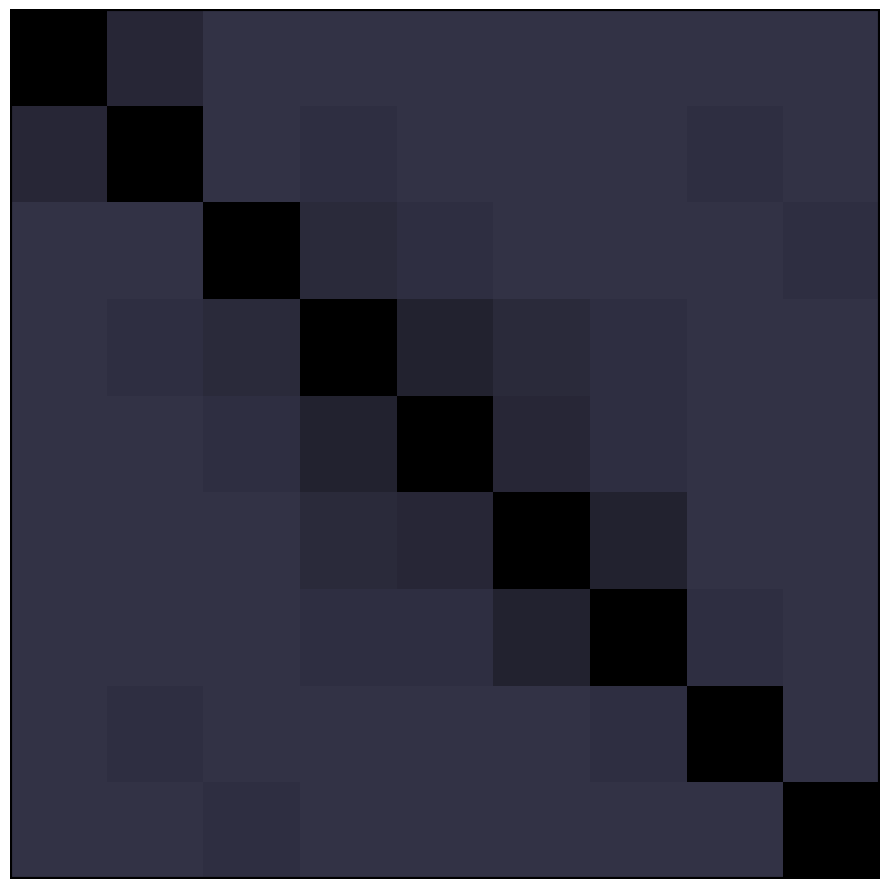

In [9]:
labels_2a = ["owl", "eagle", "flamingo", "swan", "duck", "chicken", "turkey", "dodo", "dove"]
no_species_2a = len(labels_2a)
S_2a = np.identity(n=no_species_2a)


S_2a[0][1:9] = (0.91, 0.88, 0.88, 0.88, 0.88, 0.88, 0.88, 0.88) # owl
S_2a[1][2:9] = (      0.88, 0.89, 0.88, 0.88, 0.88, 0.89, 0.88) # eagle
S_2a[2][3:9] = (            0.90, 0.89, 0.88, 0.88, 0.88, 0.89) # flamingo
S_2a[3][4:9] = (                  0.92, 0.90, 0.89, 0.88, 0.88) # swan
S_2a[4][5:9] = (                        0.91, 0.89, 0.88, 0.88) # duck
S_2a[5][6:9] = (                              0.92, 0.88, 0.88) # chicken
S_2a[6][7:9] = (                                    0.89, 0.88) # turkey
S_2a[7][8:9] = (                                          0.88) # dodo
                                                                # dove


S_2a = np.maximum( S_2a, S_2a.transpose() )
S_2a = pd.DataFrame({labels_2a[i]: S_2a[i] for i in range(no_species_2a)}, index=labels_2a)

# plot
similarity_matrix(S_2a, scale=2, outfile="fig2_community2a_birds_sim_matrix.pdf")

# save matrix
S_2a.to_csv("S_2a.csv", index=False)

In [10]:
S_2a

,owl,eagle,flamingo,swan,duck,chicken,turkey,dodo,dove
owl,1.00,0.91,0.88,0.88,0.88,0.88,0.88,0.88,0.88
eagle,0.91,1.00,0.88,0.89,0.88,0.88,0.88,0.89,0.88
flamingo,0.88,0.88,1.00,0.90,0.89,0.88,0.88,0.88,0.89
swan,0.88,0.89,0.90,1.00,0.92,0.90,0.89,0.88,0.88
duck,0.88,0.88,0.89,0.92,1.00,0.91,0.89,0.88,0.88
chicken,0.88,0.88,0.88,0.90,0.91,1.00,0.92,0.88,0.88
turkey,0.88,0.88,0.88,0.89,0.89,0.92,1.00,0.89,0.88
dodo,0.88,0.89,0.88,0.88,0.88,0.88,0.89,1.00,0.88
dove,0.88,0.88,0.89,0.88,0.88,0.88,0.88,0.88,1.00


In [11]:
counts_2a = pd.DataFrame({"Set 2a": [1, 1, 1, 1, 1, 1, 1, 1, 1]},
    index=labels_2a)
counts_2a.to_csv("counts_2a.csv", index=False)

In [12]:
counts_2a

,Set 2a
owl,1
eagle,1
flamingo,1
swan,1
duck,1
chicken,1
turkey,1
dodo,1
dove,1


In [13]:
sentropy(counts_2a, similarity=S_2a, q=0)

1.1117377343864163

### Set 2b (various animals)

Here, we care to manually make the similarities more realistic.

The species:

# 🐞🐝🦜🦋🐢🦞🦧🐠🦙

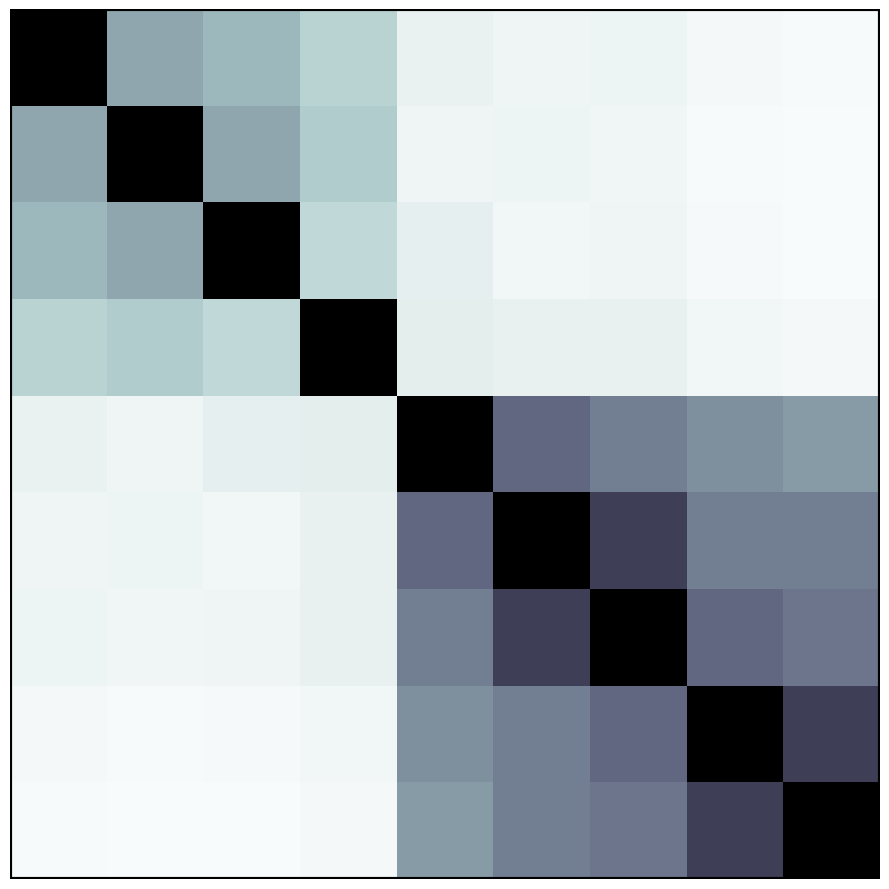

In [14]:
"""
invertebrates (insects -> arthropods) ->
fish -> reptile -> bird -> mammals

🐞🐝🦋🦞🐠🐢🦜🦙🦧
 0 1 2 3 4 5 6 7 8 
"""
# for D1Z calculation (done separately, though could import and run in this notebook, when code is ready)
labels_2b = ("ladybug", "bee", "butterfly", "lobster", "fish", "turtle", "parrot", "llama", "orangutan")

# create matrix: populate as i<j, and then symmetrize (values chosen to be consistent with Community 3's matrix)
no_species_2b = len(labels_2b)
S_2b = np.identity(n=no_species_2b)
S_2b[0][1:9] = (0.60, 0.55, 0.45, 0.25, 0.22, 0.23, 0.18, 0.16) # ladybug
S_2b[1][2:9] = (      0.60, 0.48, 0.22, 0.23, 0.21, 0.16, 0.14) # bee
S_2b[2][3:9] = (            0.42, 0.27, 0.20, 0.22, 0.17, 0.15) # butterfly
S_2b[3][4:9] = (                  0.28, 0.26, 0.26, 0.20, 0.18) # lobster
S_2b[4][5:9] = (                        0.75, 0.70, 0.66, 0.63) # fish
S_2b[5][6:9] = (                              0.85, 0.70, 0.70) # turtle
S_2b[6][7:9] = (                                    0.75, 0.72) # parrot
S_2b[7][8:9] = (                                          0.85) # llama
                                                             # orangutan
S_2b = np.maximum( S_2b, S_2b.transpose() )

S_2b = pd.DataFrame(
    {
        labels_2b[i]: S_2b[i] for i in range(no_species_2b)
    },
    index=labels_2b,
)

# plot
similarity_matrix(S_2b, scale=2, outfile="fig2_community2b_animals_sim_matrix.pdf")

# save matrix
S_2b.to_csv("S_2b.csv", index=False)

In [15]:
S_2b

,ladybug,bee,butterfly,lobster,fish,turtle,parrot,llama,orangutan
ladybug,1.00,0.60,0.55,0.45,0.25,0.22,0.23,0.18,0.16
bee,0.60,1.00,0.60,0.48,0.22,0.23,0.21,0.16,0.14
butterfly,0.55,0.60,1.00,0.42,0.27,0.20,0.22,0.17,0.15
lobster,0.45,0.48,0.42,1.00,0.28,0.26,0.26,0.20,0.18
fish,0.25,0.22,0.27,0.28,1.00,0.75,0.70,0.66,0.63
turtle,0.22,0.23,0.20,0.26,0.75,1.00,0.85,0.70,0.70
parrot,0.23,0.21,0.22,0.26,0.70,0.85,1.00,0.75,0.72
llama,0.18,0.16,0.17,0.20,0.66,0.70,0.75,1.00,0.85
orangutan,0.16,0.14,0.15,0.18,0.63,0.70,0.72,0.85,1.00


In [16]:
counts_2b = pd.DataFrame({"Set 2b": [1, 1, 1, 1, 1, 1, 1, 1, 1]},
    index=labels_2b)
counts_2b.to_csv("counts_2b.csv", index=False)

In [17]:
counts_2b

,Set 2b
ladybug,1
bee,1
butterfly,1
lobster,1
fish,1
turtle,1
parrot,1
llama,1
orangutan,1


In [18]:
sentropy(counts_2b, similarity=S_2b, q=0)

2.1631287627493374

## Figure 3: Illustrates beta diversity

In [19]:
# each phylum its own subset; expect low representativeness
subset_2b_1 = ("🐞", "🐝", "🦋", "🦞")
subset_2b_1 = ("🐠", "🐢", "🦜", "🦙", "🦧")

# each subset has members from both phyla; expect high representativeness
subset_2b_3 = ("🐞",       "🦋",       "🐠",       "🦜",       "🦧")
subset_2b_4 = (      "🐝",       "🦞",       "🐢",       "🦙",     )

In [20]:
counts_2b_1 = {"invertebrates": [1, 1, 1, 1, 0, 0, 0, 0, 0],
            "vertebrates": [0, 0, 0, 0, 1, 1, 1, 1, 1]}

In [21]:
counts_2b_1

{'invertebrates': [1, 1, 1, 1, 0, 0, 0, 0, 0],
 'vertebrates': [0, 0, 0, 0, 1, 1, 1, 1, 1]}

In [22]:
result_2b_1 = sentropy(counts_2b_1, similarity=S_2b, q=0, measure='rho_hat', level="both")
print("overall rho-hat:", result_2b_1(which="overall"))
print("rho-hat of invertebrates:", result_2b_1(which="invertebrates"))
print("rho-hat of vertebrates:", result_2b_1(which="vertebrates"))

overall rho-hat: 0.30258301207771804
rho-hat of invertebrates: 0.41333318093694116
rho-hat of vertebrates: 0.21398287699033958


In [23]:
counts_2b_2 = {"random_subset_1": [1, 0, 1, 0, 1, 0, 1, 0, 1],
                "random_subset_2": [0, 1, 0, 1, 0, 1, 0, 1, 0]}

In [24]:
counts_2b_2

{'random_subset_1': [1, 0, 1, 0, 1, 0, 1, 0, 1],
 'random_subset_2': [0, 1, 0, 1, 0, 1, 0, 1, 0]}

In [25]:
result_2b_2 = sentropy(counts_2b_2, similarity=S_2b, q=0, measure='rho_hat', level="both")
print("overall rho-hat:", result_2b_2(which="overall"))
print("rho-hat of random_subset_1:", result_2b_2(which="random_subset_1"))
print("rho-hat of random_subset_2:", result_2b_2(which="random_subset_2"))

overall rho-hat: 0.851816898053505
rho-hat of random_subset_1: 0.6782481931524431
rho-hat of random_subset_2: 1.0687777791798325
